<a href="https://colab.research.google.com/github/GeorgeT27/Generative-model-DYI/blob/main/Copy_of_Conditional_Flow_Matching_Morpho_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
import torch.distributions as distributions
from tqdm import tqdm
import pandas as pd
from copy import deepcopy
import os
import sys
sys.path.append('/workspace/Generative-model-DYI/Morpho-MNIST/')
from morphomnist import io

In [29]:
class RectifiedFlow:
  def euler(self,x_t,v,dt):
    x_t=x_t+v*dt
    return x_t
  def create_flow(self,x_1,t):
    x_0=torch.randn_like(x_1)
    t=t[:,None,None,None]
    x_t=t*x_1+(1-t)*x_0
    return x_t,x_0
  def mse_loss(self,x_1,x_0,v):
    loss=F.mse_loss(x_1-x_0,v)
    return loss

In [3]:
# Modified layers with FiLM conditioning
class FiLMLayer(nn.Module):
    """Feature-wise Linear Modulation layer for conditioning"""
    def __init__(self, num_features, condition_dim):
        super(FiLMLayer, self).__init__()
        self.scale_transform = nn.Linear(condition_dim, num_features)
        self.shift_transform = nn.Linear(condition_dim, num_features)
        
        # Initialize to identity transformation
        nn.init.zeros_(self.scale_transform.bias)
        nn.init.ones_(self.scale_transform.weight)
        nn.init.zeros_(self.shift_transform.bias)
        nn.init.zeros_(self.shift_transform.weight)
    
    def forward(self, x, condition):
        """
        Apply FiLM conditioning to features
        Args:
            x: Features [B, C, H, W]
            condition: Conditioning vector [B, condition_dim]
        """
        scale = self.scale_transform(condition).unsqueeze(-1).unsqueeze(-1)  # [B, C, 1, 1]
        shift = self.shift_transform(condition).unsqueeze(-1).unsqueeze(-1)  # [B, C, 1, 1]
        
        return x * scale + shift

class DownLayerFiLM(nn.Module):
    """MiniUnet down layer with FiLM conditioning"""
    
    def __init__(self, in_channels, out_channels, condition_dim=16, downsample=False):
        super(DownLayerFiLM, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()
        
        # FiLM conditioning layers
        self.film1 = FiLMLayer(out_channels, condition_dim)
        self.film2 = FiLMLayer(out_channels, condition_dim)
        
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None
            
        self.downsample = downsample
        if downsample:
            self.pool = nn.MaxPool2d(2)
    
    def forward(self, x, condition):
        res = x
        
        # First conv + FiLM
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.film1(x, condition)  # Apply FiLM conditioning
        x = self.act(x)
        
        # Second conv + FiLM
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.film2(x, condition)  # Apply FiLM conditioning
        x = self.act(x)
        
        if self.shortcut is not None:
            res = self.shortcut(res)
        
        x = x + res
        
        if self.downsample:
            x = self.pool(x)
            
        return x

class UpLayerFiLM(nn.Module):
    """MiniUnet up layer with FiLM conditioning"""
    
    def __init__(self, in_channels, out_channels, condition_dim=16, upsample=False):
        super(UpLayerFiLM, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()
        
        # FiLM conditioning layers
        self.film1 = FiLMLayer(out_channels, condition_dim)
        self.film2 = FiLMLayer(out_channels, condition_dim)
        
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None
            
        self.upsample = upsample
        if upsample:
            self.upsample_layer = nn.Upsample(scale_factor=2)
    
    def forward(self, x, condition):
        if self.upsample:
            x = self.upsample_layer(x)
        
        res = x
        
        # First conv + FiLM
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.film1(x, condition)
        x = self.act(x)
        
        # Second conv + FiLM
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.film2(x, condition)
        x = self.act(x)
        
        if self.shortcut is not None:
            res = self.shortcut(res)
        
        x = x + res
        return x

class MiddleLayerFiLM(nn.Module):
    """MiniUnet middle layer with FiLM conditioning"""
    
    def __init__(self, in_channels, out_channels, condition_dim=16):
        super(MiddleLayerFiLM, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU()
        
        # FiLM conditioning layers
        self.film1 = FiLMLayer(out_channels, condition_dim)
        self.film2 = FiLMLayer(out_channels, condition_dim)
        
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None
    
    def forward(self, x, condition):
        res = x
        
        # First conv + FiLM
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.film1(x, condition)
        x = self.act(x)
        
        # Second conv + FiLM
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.film2(x, condition)
        x = self.act(x)
        
        if self.shortcut is not None:
            res = self.shortcut(res)
        
        x = x + res
        return x

class MiniUnetFiLM(nn.Module):
    """MiniUnet with FiLM conditioning for better morphometric control"""
    
    def __init__(self, base_channels=16, condition_dim=None, use_morphometrics=False):
        super(MiniUnetFiLM, self).__init__()
        
        if condition_dim is None:
            self.condition_dim = base_channels * 2  # Larger condition space
        else:
            self.condition_dim = condition_dim
            
        self.base_channels = base_channels
        self.use_morphometrics = use_morphometrics
        
        self.conv_in = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)
        
        # Improved morphometric embedding
        if use_morphometrics:
            self.area_proj = nn.Sequential(
                nn.Linear(1, self.condition_dim // 4),
                nn.ReLU(),
                nn.Linear(self.condition_dim // 4, self.condition_dim // 4)
            )
            self.thickness_proj = nn.Sequential(
                nn.Linear(1, self.condition_dim // 4),
                nn.ReLU(),
                nn.Linear(self.condition_dim // 4, self.condition_dim // 4)
            )
            self.length_proj = nn.Sequential(
                nn.Linear(1, self.condition_dim // 4),
                nn.ReLU(),
                nn.Linear(self.condition_dim // 4, self.condition_dim // 4)
            )
            
            # Fusion layer for morphometric features
            self.morpho_fusion = nn.Sequential(
                nn.Linear(self.condition_dim // 4 * 3, self.condition_dim),
                nn.ReLU(),
                nn.Linear(self.condition_dim, self.condition_dim)
            )
        
        # U-Net architecture with FiLM conditioning
        self.down1 = nn.ModuleList([
            DownLayerFiLM(base_channels, base_channels * 2, self.condition_dim),
            DownLayerFiLM(base_channels * 2, base_channels * 2, self.condition_dim)
        ])
        self.maxpool1 = nn.MaxPool2d(2)
        
        self.down2 = nn.ModuleList([
            DownLayerFiLM(base_channels * 2, base_channels * 4, self.condition_dim),
            DownLayerFiLM(base_channels * 4, base_channels * 4, self.condition_dim)
        ])
        self.maxpool2 = nn.MaxPool2d(2)
        
        self.middle = MiddleLayerFiLM(base_channels * 4, base_channels * 4, self.condition_dim)
        
        self.upsample1 = nn.Upsample(scale_factor=2)
        self.up1 = nn.ModuleList([
            UpLayerFiLM(base_channels * 8, base_channels * 2, self.condition_dim),
            UpLayerFiLM(base_channels * 2, base_channels * 2, self.condition_dim)
        ])
        
        self.upsample2 = nn.Upsample(scale_factor=2)
        self.up2 = nn.ModuleList([
            UpLayerFiLM(base_channels * 4, base_channels, self.condition_dim),
            UpLayerFiLM(base_channels, base_channels, self.condition_dim)
        ])
        
        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=1, padding=0)
    
    def time_emb(self, t, dim):
        """Enhanced time embedding"""
        t = t * 1000
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(t.device)
        sin_emb = torch.sin(t[:, None] / freqs)
        cos_emb = torch.cos(t[:, None] / freqs)
        return torch.cat([sin_emb, cos_emb], dim=-1)
    
    def label_emb(self, y, dim):
        """Enhanced label embedding"""
        y = y * 1000
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(y.device)
        sin_emb = torch.sin(y[:, None] / freqs)
        cos_emb = torch.cos(y[:, None] / freqs)
        return torch.cat([sin_emb, cos_emb], dim=-1)
    
    def morphometric_emb(self, morpho_dict):
        """Enhanced morphometric embedding with proper normalization"""
        if not self.use_morphometrics or morpho_dict is None:
            batch_size = morpho_dict['area'].size(0) if morpho_dict else 1
            return torch.zeros(batch_size, self.condition_dim, 
                             device=next(self.parameters()).device)
        
        # Use actual training statistics (corrected values)
        area_mean, area_std = 112.79, 84.32
        thickness_mean, thickness_std = 3.13, 1.98
        length_mean, length_std = 37.38, 10.47
        
        # Normalize features properly
        area_norm = (morpho_dict['area'] - area_mean) / area_std
        thickness_norm = (morpho_dict['thickness'] - thickness_mean) / thickness_std
        length_norm = (morpho_dict['length'] - length_mean) / length_std
        
        # Clamp to reasonable range
        area_norm = torch.clamp(area_norm, -3, 3)
        thickness_norm = torch.clamp(thickness_norm, -3, 3)
        length_norm = torch.clamp(length_norm, -3, 3)
        
        # Project to embedding space
        area_emb = self.area_proj(area_norm.unsqueeze(-1))
        thickness_emb = self.thickness_proj(thickness_norm.unsqueeze(-1))
        length_emb = self.length_proj(length_norm.unsqueeze(-1))
        
        # Fuse morphometric features
        morpho_concat = torch.cat([area_emb, thickness_emb, length_emb], dim=-1)
        morpho_emb = self.morpho_fusion(morpho_concat)
        
        return morpho_emb
    
    def forward(self, x, t, y=None, morpho=None):
        """Forward pass with FiLM conditioning"""
        x = self.conv_in(x)
        
        # Build comprehensive condition vector
        condition = self.time_emb(t, self.condition_dim)
        
        # Add label conditioning
        if y is not None:
            if len(y.shape) == 1:
                yemb = self.label_emb(y, self.condition_dim)
                yemb[y == -1] = 0.0  # Zero out unconditional samples
                condition = condition + yemb
        
        # Add morphometric conditioning
        if morpho is not None and self.use_morphometrics:
            morpho_emb = self.morphometric_emb(morpho)
            condition = condition + morpho_emb
        
        # Encoder path with FiLM conditioning
        for layer in self.down1:
            x = layer(x, condition)
        x1 = x
        x = self.maxpool1(x)
        
        for layer in self.down2:
            x = layer(x, condition)
        x2 = x
        x = self.maxpool2(x)
        
        # Middle layer
        x = self.middle(x, condition)
        
        # Decoder path with FiLM conditioning
        x = torch.cat([self.upsample1(x), x2], dim=1)
        for layer in self.up1:
            x = layer(x, condition)
        
        x = torch.cat([self.upsample2(x), x1], dim=1)
        for layer in self.up2:
            x = layer(x, condition)
        
        x = self.conv_out(x)
        return x


In [4]:
class EMA(nn.Module):
    def __init__(self, model, decay=0.9999, device=None):
        super(EMA, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()
        self.decay = decay
        self.device = device  # perform EMA on different device from model if set
        if self.device is not None:
            self.module.to(device=self.device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(),
                                      model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(
            model,
            update_fn=lambda e, m: self.decay * e + (1.0 - self.decay) * m
        )

    def set(self, model):
        self._update(
            model,
            update_fn=lambda e, m: m
        )

In [5]:
# Improved training configuration
epochs= 200  # More epochs
batch_size= 128  # Larger batch size for more stable gradients
lr= 5e-4  # Slightly higher learning rate initially
weight_decay= 1e-4  # Less regularization
ema_decay= 0.9999
grad_clip= 1.0
lr_schedule= True
step_size= 40  # Reduce LR later
gamma= 0.5 # More gradual LR reduction
lr_adjust_epoch= 25 # 学习率调整的epoch，降为原有的10%
batch_print_interval= 100 # 打印间隔，以batch为单位
device= 'cuda' # cuda、cpu、mps(only macbook)
checkpoint_save_interval= 10 # 模型保存间隔，以epoch为单位

## Download Morpho-MNIST Dataset

Morpho-MNIST provides several dataset variants:

- **plain**: Plain digits only (16 MB)
- **global**: Plain + thinning + thickening (15 MB)  
- **local**: Plain + swelling + fractures (16 MB)
- **thin**: Thinning only (13 MB)
- **thic**: Thickening only (16 MB)
- **swel**: Swelling only (17 MB)
- **frac**: Fractures only (16 MB)

### Manual Download Required:
1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL
2. Download one of the datasets (e.g., "global" for diverse perturbations)
3. Extract to: `/Users/tqa946816/Generative-model-DYI/data/morpho-mnist/`

### Dataset Structure:
Each dataset contains:
- `[train|t10k]-images-idx3-ubyte.gz`: Images
- `[train|t10k]-labels-idx1-ubyte.gz`: Digit labels (0-9)
- `[train|t10k]-morpho.csv`: Morphometrics (area, length, thickness, slant, width, height)
- `[train|t10k]-pert-idx1-ubyte.gz`: Perturbation labels (0: plain, 1: thinned, 2: thickened, 3: swollen, 4: fractured)

In [ ]:
class MorphoMNISTDataset(torch.utils.data.Dataset):
    """Custom dataset class for Morpho-MNIST data"""

    def __init__(self, root, train=True, download=False, transform=None,
                 load_morphometrics=False, load_perturbations=False):
        self.root = root
        self.train = train
        self.transform = transform
        self.load_morphometrics = load_morphometrics
        self.load_perturbations = load_perturbations

        # Create morpho-mnist directory
        self.morpho_dir = os.path.join(root, 'Morpho_MNIST/global')
        if not os.path.exists(self.morpho_dir):
            os.makedirs(self.morpho_dir)

        if download:
            self.download_data()

        # Load data
        self.data, self.targets, self.morphometrics, self.perturbations = self._load_data()

    def download_data(self):
        """Download Morpho-MNIST data if not exists"""
        print("Please download Morpho-MNIST data manually from:")
        print("https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL")
        print("Choose one of: plain, global, local, thin, thic, swel, frac")
        print(f"Extract to: {self.morpho_dir}")

    def _load_data(self):
        """Load Morpho-MNIST data files"""
        prefix = 'train' if self.train else 't10k'

        # Load images
        images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte.gz')
        if os.path.exists(images_file):
            images = io.load_idx(images_file)
        else:
            raise FileNotFoundError(f"Images file not found: {images_file}")

        # Load labels
        labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte.gz')

        if os.path.exists(labels_file):
            labels = io.load_idx(labels_file)
        else:
            raise FileNotFoundError(f"Labels file not found: {labels_file}")

        # Load morphometrics (CSV file) - only if requested
        morphometrics = None
        if self.load_morphometrics:
            morpho_file = os.path.join(self.morpho_dir, f'{prefix}-morpho.csv')
            if os.path.exists(morpho_file):
                morphometrics = pd.read_csv(morpho_file)
            else:
                print(f"Warning: Morphometrics file not found: {morpho_file}")

        # Load perturbation labels (if available) - only if requested
        perturbations = None
        if self.load_perturbations:
            pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte.gz')
            if not os.path.exists(pert_file):
                pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte')

            if os.path.exists(pert_file):
                perturbations = io.load_idx(pert_file)
            else:
                print(f"Warning: Perturbation file not found: {pert_file}")

        return images, labels, morphometrics, perturbations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        target = self.targets[idx]

        # Convert to tensor and normalize to [0, 1]
        image = torch.from_numpy(image).float() / 255.0
        image = image.unsqueeze(0)  # Add channel dimension

        if self.transform:
            image = self.transform(image)

        # You can also return morphometrics and perturbations if needed
        sample = {
            'image': image,
            'target': target,
        }

        if self.morphometrics is not None:
            morpho_data = self.morphometrics.iloc[idx]
            sample['morphometrics'] = {
                'area': morpho_data['area'],
                'length': morpho_data['length'],
                'thickness': morpho_data['thickness'],
                'slant': morpho_data['slant'],
                'width': morpho_data['width'],
                'height': morpho_data['height']
            }

        if self.perturbations is not None:
            sample['perturbation'] = self.perturbations[idx]

        return sample

Morpho Mnist

In [ ]:
# Option 1: Basic usage (no morphometrics/perturbations) - Most memory efficient
dataset = MorphoMNISTDataset(
    root='/workspace/Generative-model-DYI/data',
    train=True,
    download=False,  # Will show download instructions
    transform=None,  # We handle normalization in the custom dataset
    load_morphometrics=True,  # Don't load morphometrics to save memory
    load_perturbations=True   # Don't load perturbations to save memory
)


def morpho_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = torch.tensor([item['target'] for item in batch])

    # Extract morphometric features into tensors
    morphometrics = None
    if any('morphometrics' in item for item in batch):
        morpho_data = [item.get('morphometrics', None) for item in batch]
        if morpho_data[0] is not None:  # Check if morphometrics are actually loaded
            morphometrics = {
                'area': torch.tensor([m['area'] for m in morpho_data], dtype=torch.float32),
                'thickness': torch.tensor([m['thickness'] for m in morpho_data], dtype=torch.float32),
                'length': torch.tensor([m['length'] for m in morpho_data], dtype=torch.float32),
            }

    return images, targets, morphometrics


In [ ]:
dataset=Mnist

In [23]:
#Simple test
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=morpho_collate_fn)
data_iter=iter(dataloader)
sample_batch=next(data_iter)
data,labels,morpho=sample_batch
print(data.shape,labels.shape,morpho['area'].shape, morpho['thickness'].shape, morpho['length'].shape)

torch.Size([128, 1, 28, 28]) torch.Size([128]) torch.Size([128]) torch.Size([128]) torch.Size([128])


In [24]:
# Create model with morphometric conditioning enabled
model = MiniUnetFiLM(base_channels=16,condition_dim=64 ,use_morphometrics=True).to(device)
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = StepLR(optimizer, step_size=step_size, gamma=gamma)
rf = RectifiedFlow()
ema = EMA(model, decay=0.999, device=device)

for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    epoch_losses=[]
    for batch_idx, (data, label, morpho) in enumerate(pbar):  # Now unpack morphometrics too
        x_1 = data
        y = label

        t = torch.rand(x_1.size(0))
        x_t, x_0 = rf.create_flow(x_1, t)

        # Move to device
        x_t = x_t.to(device)
        x_0 = x_0.to(device)
        x_1 = x_1.to(device)
        t = t.to(device)
        y = y.to(device)

        # Move morphometrics to device
        if morpho is not None:
            morpho = {k: v.to(device) for k, v in morpho.items()}

        optimizer.zero_grad()

        # Train with both conditional and unconditional
        x_t = torch.cat([x_t, x_t.clone()], dim=0)
        x_0 = torch.cat([x_0, x_0.clone()], dim=0)
        x_1 = torch.cat([x_1, x_1.clone()], dim=0)
        t = torch.cat([t, t.clone()], dim=0)
        y = torch.cat([y, -torch.ones_like(y)], dim=0)

        # Duplicate morphometrics for conditional/unconditional training
        if morpho is not None:
            morpho_batch = {}
            for k, v in morpho.items():
                # First half: real morphometrics, second half: zeros (unconditional)
                morpho_batch[k] = torch.cat([v, torch.zeros_like(v)], dim=0)
        else:
            morpho_batch = None

        # Forward pass with morphometric conditioning
        v_pred = model(x_t, t, y, morpho_batch)

        loss = rf.mse_loss(x_1, x_0, v_pred)
        if torch.isnan(loss):
          print(f'Warning:Nan loss detected at epoch {epoch}, batch {batch_idx}')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

        epoch_losses.append(loss.item())
        if len(epoch_losses)>0:
          avg_loss=sum(epoch_losses[-10:])/len(epoch_losses[-10:])
          pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg_loss': f'{avg_loss:.4f}'})
        else:
          pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    epoch_avg_loss=sum(epoch_losses)/len(epoch_losses) if epoch_losses else float('inf')
    print(f'Epoch {epoch}: average loss= {epoch_avg_loss:.6f}')
    if lr_schedule:
        schedular.step()
    if epoch % 5 == 0:
        torch.save({
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': loss
        }, f"morpho_ckpt_{epoch}.pth")


Epoch 0: 100%|██████████| 79/79 [00:02<00:00, 36.24it/s, loss=1.5749, avg_loss=1.3482]


Epoch 0: 100%|██████████| 79/79 [00:02<00:00, 36.24it/s, loss=1.5749, avg_loss=1.3482]


Epoch 0: average loss= 33.010507


Epoch 1:  30%|███       | 24/79 [00:00<00:01, 37.12it/s, loss=1.0972, avg_loss=1.2058]

Epoch 0: 100%|██████████| 79/79 [00:02<00:00, 36.24it/s, loss=1.5749, avg_loss=1.3482]


...

Epoch 36: average loss= 0.370620


Epoch 37: 100%|██████████| 79/79 [00:02<00:00, 36.70it/s, loss=0.1292, avg_loss=0.1519]


Epoch 37: average loss= 0.271728


Epoch 38:   9%|▉         | 7/79 [00:00<00:02, 33.68it/s, loss=0.1551, avg_loss=0.5272]



KeyboardInterrupt: 


Generating samples with improved morphometric conditioning...
Generating 4 samples using FiLM EMA model...
Using 100 integration steps for high quality...
Label conditioning: tensor([7, 7, 7, 7])
Morphometric conditioning:
  area: tensor([ 80., 120., 160., 200.])
  thickness: tensor([1.5000, 2.0000, 2.5000, 3.0000])
  length: tensor([30., 35., 40., 45.])
Visualizing samples...
Visualizing samples...



Generating samples with improved morphometric conditioning...
Generating 4 samples using FiLM EMA model...
Using 100 integration steps for high quality...
Label conditioning: tensor([7, 7, 7, 7])
Morphometric conditioning:
  area: tensor([ 80., 120., 160., 200.])
  thickness: tensor([1.5000, 2.0000, 2.5000, 3.0000])
  length: tensor([30., 35., 40., 45.])
Visualizing samples...
Visualizing samples...


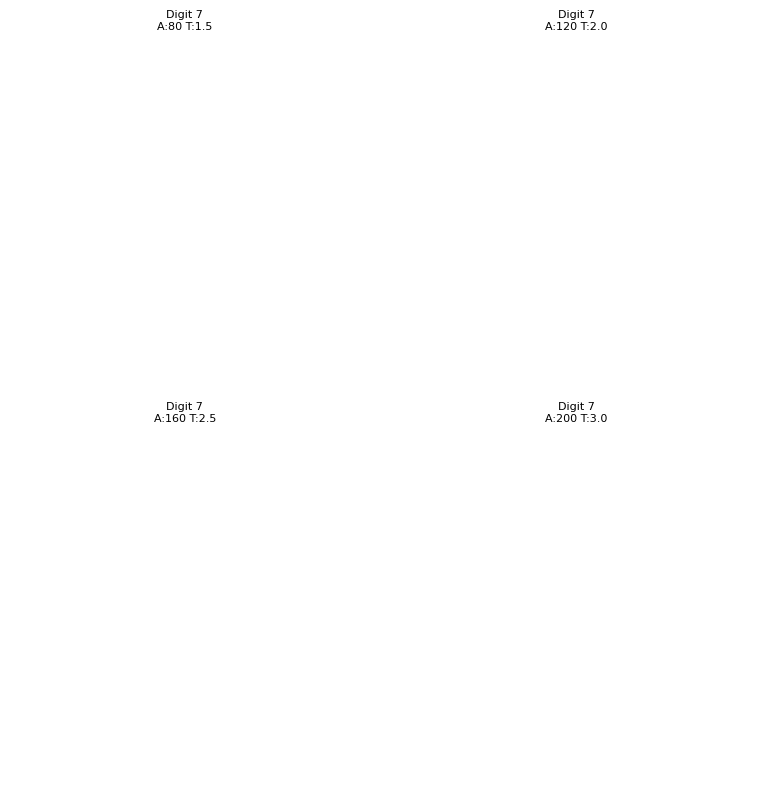

Sample generation completed!


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def sample(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples using the trained FiLM flow matching model

    Args:
        model: Trained MiniUnetFiLM model
        rf: RectifiedFlow instance
        num_samples: Number of samples to generate
        cfg_scale: Classifier-free guidance scale
        y: Labels for conditioning (optional)
        morpho: Morphometric features for conditioning (optional)
        num_steps: Number of integration steps
        device: Device to run on
    """
    # Handle label conditioning
    if y is not None:
        assert len(y.shape) == 1, 'y must be 1D tensor'
        if y.shape[0] == 1:
            y = y.repeat(num_samples)
        elif y.shape[0] != num_samples:
            # If different number of labels, repeat the first one
            y = y[0].repeat(num_samples)
        y = y.to(device)

    # Handle morphometric conditioning
    if morpho is not None:
        morpho_device = {}
        for k, v in morpho.items():
            if v.shape[0] == 1:
                morpho_device[k] = v.repeat(num_samples).to(device)
            elif v.shape[0] != num_samples:
                # If different number of morpho values, repeat to match num_samples
                morpho_device[k] = v[:num_samples].to(device) if v.shape[0] >= num_samples else v[0].repeat(num_samples).to(device)
            else:
                morpho_device[k] = v.to(device)
        morpho = morpho_device

    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        # Start from noise
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Integrate the flow from t=0 to t=1
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Unconditional prediction (no labels, no morphometrics)
            v_pred_uncon = model(x_t, t, y=None, morpho=None)

            # Conditional prediction with both labels and morphometrics
            v_pred_con = model(x_t, t, y=y, morpho=morpho)

            # Classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def sample_with_varied_conditioning(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples with more flexible conditioning options for FiLM model
    
    This function allows for different combinations of label and morphometric conditioning
    """
    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Handle conditioning inputs
        if y is not None:
            y = y.to(device)
            if len(y.shape) == 0:  # Single value
                y = y.repeat(num_samples)
            elif y.shape[0] != num_samples:
                y = y[:num_samples] if y.shape[0] >= num_samples else y[0].repeat(num_samples)

        if morpho is not None:
            morpho_processed = {}
            for k, v in morpho.items():
                v = v.to(device)
                if v.shape[0] != num_samples:
                    if v.shape[0] == 1:
                        morpho_processed[k] = v.repeat(num_samples)
                    else:
                        morpho_processed[k] = v[:num_samples] if v.shape[0] >= num_samples else v[0].repeat(num_samples)
                else:
                    morpho_processed[k] = v
            morpho = morpho_processed

        # Integration loop
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Get unconditional and conditional predictions
            v_pred_uncon = model(x_t, t, y=None, morpho=None)
            v_pred_con = model(x_t, t, y=y, morpho=morpho)

            # Apply classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def visualize_samples(samples, num_display=16, figsize=(8, 8), titles=None):
    """Enhanced visualization with optional titles"""
    samples = samples.cpu().numpy()
    samples = np.clip(samples, 0, 1)

    grid_size = int(np.sqrt(num_display))
    if grid_size * grid_size < num_display:
        grid_size += 1

    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten() if num_display > 1 else [axes]

    for i in range(grid_size * grid_size):
        if i < len(samples) and i < num_display:
            img = samples[i, 0]
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
            if titles and i < len(titles):
                axes[i].set_title(titles[i], fontsize=8)
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def generate_samples_with_ema(ema_model, rf, cfg_scale, y=None, morpho=None, num_samples=16, num_steps=100, device='cuda'):
    """Updated generation function for FiLM EMA model"""
    print(f"Generating {num_samples} samples using FiLM EMA model...")
    print(f"Using {num_steps} integration steps for high quality...")
    
    if y is not None:
        print(f"Label conditioning: {y}")
    if morpho is not None:
        print(f"Morphometric conditioning:")
        for k, v in morpho.items():
            print(f"  {k}: {v}")

    # Generate samples using the updated sample function
    samples = sample(ema_model, rf, num_samples=num_samples, cfg_scale=cfg_scale, 
                    y=y, morpho=morpho, num_steps=num_steps, device=device)

    print("Visualizing samples...")
    
    # Create titles for visualization
    titles = []
    if y is not None and morpho is not None:
        for i in range(min(num_samples, 16)):
            y_val = y[i] if i < len(y) else y[0]
            area_val = morpho['area'][i] if i < len(morpho['area']) else morpho['area'][0]
            thick_val = morpho['thickness'][i] if i < len(morpho['thickness']) else morpho['thickness'][0]
            titles.append(f"Digit {y_val.item():.0f}\nA:{area_val:.0f} T:{thick_val:.1f}")
    
    visualize_samples(samples, num_samples, titles=titles)
    return samples

# Test the updated sampling with better morphometric conditioning
def test_morphometric_conditioning(ema_model, rf, device='cuda'):
    """Test function to demonstrate morphometric conditioning capabilities"""
    print("Testing morphometric conditioning with FiLM model...")
    
    # Test 1: Same digit, different areas
    print("\n1. Testing area variation (digit 7):")
    morpho_area_test = {
        'area': torch.tensor([50.0, 100.0, 150.0, 200.0]),
        'thickness': torch.tensor([2.5, 2.5, 2.5, 2.5]),
        'length': torch.tensor([35.0, 35.0, 35.0, 35.0])
    }
    samples_area = generate_samples_with_ema(
        ema_model, rf, cfg_scale=7,
        y=torch.tensor([7, 7, 7, 7]),
        morpho=morpho_area_test,
        num_samples=4, num_steps=100, device=device
    )
    
    # Test 2: Same digit, different thickness
    print("\n2. Testing thickness variation (digit 3):")
    morpho_thickness_test = {
        'area': torch.tensor([120.0, 120.0, 120.0, 120.0]),
        'thickness': torch.tensor([1.0, 2.0, 3.0, 4.0]),
        'length': torch.tensor([35.0, 35.0, 35.0, 35.0])
    }
    samples_thickness = generate_samples_with_ema(
        ema_model, rf, cfg_scale=7,
        y=torch.tensor([3, 3, 3, 3]),
        morpho=morpho_thickness_test,
        num_samples=4, num_steps=100, device=device
    )
    
    return samples_area, samples_thickness

# Update your existing model usage
sampling_model = ema.module
sampling_model.eval()

print("\nGenerating samples with improved morphometric conditioning...")
morpho_condition = {
    'area': torch.tensor([80.0, 120.0, 160.0, 200.0]),     # Small to large areas
    'thickness': torch.tensor([1.5, 2.0, 2.5, 3.0]),       # Thin to thick
    'length': torch.tensor([30.0, 35.0, 40.0, 45.0])       # Short to long
}

samples_morpho = generate_samples_with_ema(
    sampling_model, rf,
    y=torch.tensor([7, 7, 7, 7]),  # All digit "7" but with different morphometrics
    morpho=morpho_condition,
    cfg_scale=7,
    num_samples=4,
    num_steps=100,
    device=device
)

print("Sample generation completed!")